# 01 — EDA: Online Shoppers Purchasing Intention

**Goal:** Predict whether a web session ends in a purchase (`Revenue` = True/False).

This notebook explores the raw data and surfaces the decisions that drive the MLOps pipeline:
data-quality rules (Sprint 1, Great Expectations), cleaning/encoding (Sprint 2), the success metric
(imbalance), and the **natural seasonal drift** story (Sprint 4, req #5).

> Run this with the Anaconda Python environment (it has pandas / matplotlib / seaborn).

**Dataset:** UCI id=468, `online_shoppers_intention.csv` — 12,330 sessions, 18 columns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Notebook lives in Main Project/notebooks/ ; data is one level up
DATA_PATH = "../online_shoppers_intention.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 1. Structure, types, and integrity

First questions any data-quality gate must answer: right shape? right types? missing? duplicates?

In [2]:
print("=== dtypes ===")
print(df.dtypes)
print("\n=== missing values ===")
missing = df.isna().sum()
print(missing[missing > 0] if missing.sum() else "No missing values")
print("\n=== duplicate rows ===", df.duplicated().sum())

=== dtypes ===
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

=== missing values ===
No missing values

=== duplicate rows === 125


**Finding:** no missing values, but **125 duplicate rows**.

*Pipeline implication:* a de-duplication step (Sprint 2 cleaning) and a Great Expectations uniqueness
check (Sprint 1). We also note there is **no ID column** — we will create a `session_id` for the
feature-store primary key.

## 2. Target balance — `Revenue`

The single most important number for choosing the success metric.

Revenue
False    10422
True      1908
Name: count, dtype: int64

Purchase rate: 15.47%


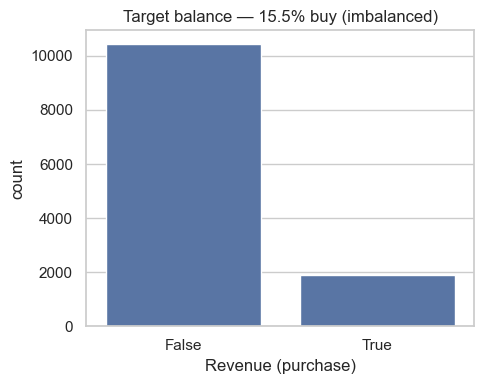

In [3]:
counts = df["Revenue"].value_counts()
rate = df["Revenue"].mean() * 100
print(counts)
print(f"\nPurchase rate: {rate:.2f}%")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Revenue", data=df, ax=ax)
ax.set_title(f"Target balance — {rate:.1f}% buy (imbalanced)")
ax.set_xlabel("Revenue (purchase)")
plt.tight_layout()
plt.show()

**Finding:** only **15.5%** of sessions purchase → **class imbalance**.

*Pipeline implication:* **accuracy is misleading** (predicting "nobody buys" scores ~84.5%). The report's
**success metric** is therefore **recall on buyers / F1 / ROC-AUC**, optionally cost-weighted (value of a
captured buyer vs. cost of a false offer). This matches the course point: *marry the metric to the business goal.*

## 3. The star signal — `PageValues`

`PageValues` = average value of the pages a user visited before the session. Strong purchase intent proxy.

mean PageValues | bought : 27.26
mean PageValues | no buy : 1.98
ratio: 13.8x


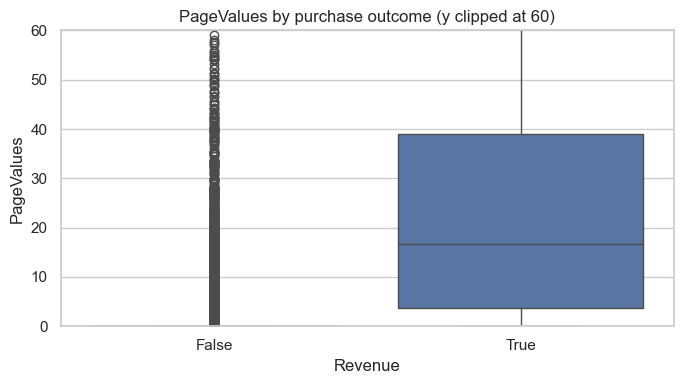

In [4]:
buy = df[df["Revenue"]]["PageValues"].mean()
nobuy = df[~df["Revenue"]]["PageValues"].mean()
print(f"mean PageValues | bought : {buy:.2f}")
print(f"mean PageValues | no buy : {nobuy:.2f}")
print(f"ratio: {buy / nobuy:.1f}x")

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x="Revenue", y="PageValues", data=df, ax=ax)
ax.set_ylim(0, 60)  # clip extreme outliers for readability
ax.set_title("PageValues by purchase outcome (y clipped at 60)")
plt.tight_layout()
plt.show()

**Finding:** buyers average **~27** vs non-buyers **~2** — a **~14x** gap.

*Pipeline implication:* `PageValues` will almost certainly be the **#1 SHAP feature** (Sprint 2/6) —
a clean, intuitive explainability headline for the report.

## 4. The drift axis — purchase rate by `Month`

This is what makes the dataset's **data-drift component (req #5) genuine rather than simulated.**

Month
Feb      1.6
Mar     10.1
May     10.9
June    10.1
Jul     15.3
Aug     17.6
Sep     19.2
Oct     20.9
Nov     25.4
Dec     12.5
Name: Revenue, dtype: float64


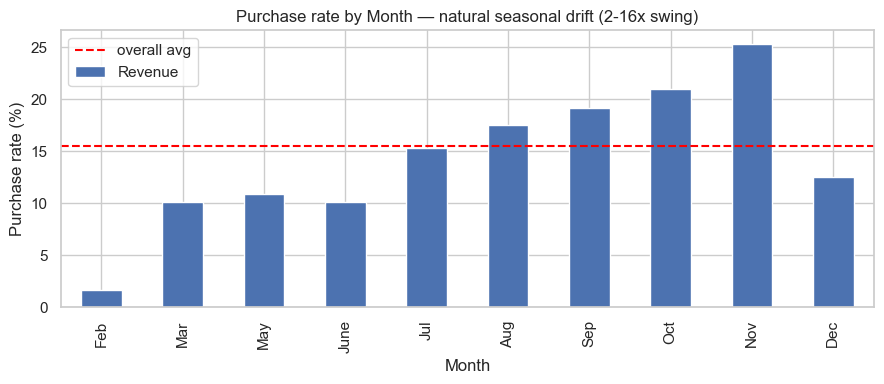

In [5]:
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
by_month = (df.groupby("Month")["Revenue"].mean() * 100).reindex(month_order)
print(by_month.round(1))

fig, ax = plt.subplots(figsize=(9, 4))
by_month.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Purchase rate by Month — natural seasonal drift (2-16x swing)")
ax.set_ylabel("Purchase rate (%)")
ax.axhline(df["Revenue"].mean() * 100, color="red", ls="--", label="overall avg")
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** purchase rate swings from **Feb 1.6%** to **Nov 25.4%** — a 2-16x seasonal swing
(holiday season drives buying). Note: no Jan/Apr in the data.

*Pipeline implication (Sprint 4, req #5):* use a **time-based reference/current split** — train the
drift reference on lower-season months and feed a holiday-season batch (e.g. Nov) as the "current"
window. Evidently then detects a **real** distribution shift with a believable business cause — a
stronger story than randomly perturbing a column.

## 5. Categoricals (incl. the "numeric but categorical" trap)

`OperatingSystems`, `Browser`, `Region`, `TrafficType` are stored as integers but are **categories** —
OS "2" is not "twice" OS "1". Treating them as magnitudes would be a modelling error.

In [6]:
for c in ["Month", "VisitorType", "Weekend"]:
    print(f"-- {c} --")
    print(df[c].value_counts(), "\n")

print("=== integer-encoded categoricals (n unique) ===")
for c in ["OperatingSystems", "Browser", "Region", "TrafficType"]:
    print(f"{c:18s} -> {df[c].nunique()} categories")

-- Month --
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64 

-- VisitorType --
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64 

-- Weekend --
Weekend
False    9462
True     2868
Name: count, dtype: int64 

=== integer-encoded categoricals (n unique) ===
OperatingSystems   -> 8 categories
Browser            -> 13 categories
Region             -> 9 categories
TrafficType        -> 20 categories


**Finding:** `VisitorType` is 88% returning visitors; `OperatingSystems`(8), `Browser`(13),
`Region`(9), `TrafficType`(20) are integer-coded categories.

*Pipeline implication (Sprint 2):* one-hot / target-encode these (do **not** scale them as numbers).
`Revenue` and `Weekend` bool -> int. This 'we used judgement, not blind automation' choice is a
good report point (the course flags it explicitly for Featuretools).

## 6. Numeric ranges & skew (sets up the GX range checks)

In [7]:
num_cols = [
    "Administrative", "Administrative_Duration", "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration", "BounceRates", "ExitRates",
    "PageValues", "SpecialDay",
]
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.32,3.32,0.0,0.00,1.00,4.00,27.00
Administrative_Duration,12330.0,80.82,176.78,0.0,0.00,7.50,93.26,3398.75
Informational,12330.0,0.50,1.27,0.0,0.00,0.00,0.00,24.00
Informational_Duration,12330.0,34.47,140.75,0.0,0.00,0.00,0.00,2549.38
ProductRelated,12330.0,31.73,44.48,0.0,7.00,18.00,38.00,705.00
ProductRelated_Duration,12330.0,1194.75,1913.67,0.0,184.14,598.94,1464.16,63973.52
BounceRates,12330.0,0.02,0.05,0.0,0.00,0.00,0.02,0.20
ExitRates,12330.0,0.04,0.05,0.0,0.01,0.03,0.05,0.20
PageValues,12330.0,5.89,18.57,0.0,0.00,0.00,0.00,361.76
SpecialDay,12330.0,0.06,0.20,0.0,0.00,0.00,0.00,1.00


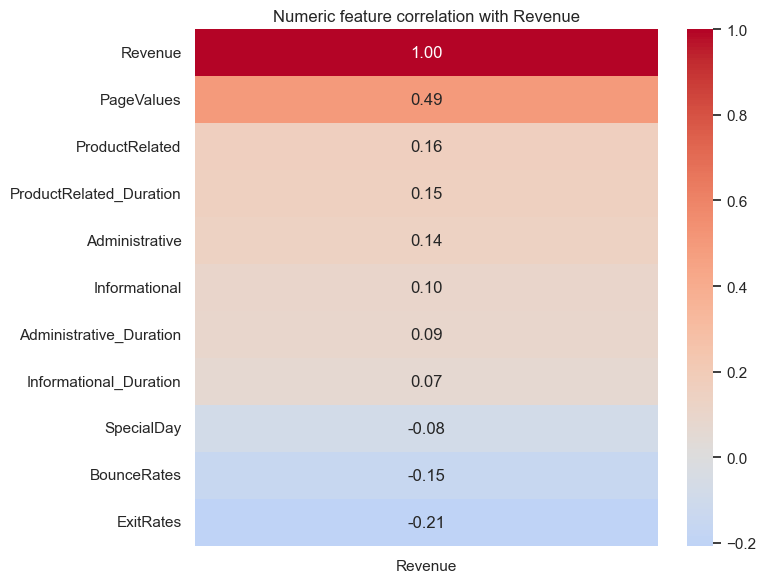

In [8]:
# Correlation of numeric features with the target
corr = df[num_cols + ["Revenue"]].copy()
corr["Revenue"] = corr["Revenue"].astype(int)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr.corr()[["Revenue"]].sort_values("Revenue", ascending=False),
            annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric feature correlation with Revenue")
plt.tight_layout()
plt.show()

**Finding:** `BounceRates`/`ExitRates` are bounded in [0, ~0.2]; durations are >= 0 and heavily
right-skewed (e.g. `ProductRelated_Duration` max ~64,000s); `SpecialDay` in [0, 1]. `PageValues`
has the strongest positive correlation with purchase.

*Pipeline implication (Sprint 1, req #1 — Great Expectations):* these bounds become **range
expectations** — e.g. `ExitRates`/`BounceRates` between 0 and 1, all durations >= 0, `SpecialDay`
between 0 and 1, `Revenue` in {True, False}. Skew/outliers in durations become a scaling decision in Sprint 2.

## 7. Summary — EDA findings mapped to pipeline sprints

| Finding | Becomes (sprint) |
|---|---|
| No missing; 125 duplicates; no ID col | dedup node + GX uniqueness; create `session_id` (S1/S2) |
| 15.5% purchase (imbalance) | metric = recall/F1/ROC-AUC, maybe class weights (S2) |
| `ExitRates`/`BounceRates` in [0, 0.2], durations >= 0, `SpecialDay` in [0,1] | GX **range expectations** (S1, req #1) |
| OS/Browser/Region/TrafficType are categorical ints | encoding decision, not scaling (S2) |
| `Month` drives purchase 2-16x | **natural drift** reference/current split (S4, req #5) |
| `PageValues` ~14x gap buyers vs not | **SHAP headline** for the report (S2/S6) |

Next: **Sprint 1** — turn the range/uniqueness/type findings above into a Great Expectations suite
(>= 6 asserts) inside the `data_quality` Kedro pipeline.